In [ ]:
# Install required packages.
import os
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

2.5.1+cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 54.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 35.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!pip install pyg-lib torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.5.1+cpu.html


Looking in links: https://data.pyg.org/whl/torch-2.5.1+cpu.html


# Introduction: What is it used for, and where does it fit in a complex task?

Embeddings are used to represent complex data structures (like nodes in a graph) as low-dimensional vectors that capture meaningful patterns and relationships. They are typically used in the **feature representation stage** of a complex pipeline, serving as the bridge between upstream data preparation tasks and downstream applications.

Let's look at how embeddings fit into a larger workflow using the example of a large social network platform (e.g., Facebook), where users (nodes) are connected by friend relationships (edges). Our goal is to improve overall user experience. Here's the typical workflow, divided into upstream and downstream tasks, and where embeddings come into play.

## Upstream Tasks
Upstream tasks involve a series of data engineering steps to provide the foundation for downstream tasks. These include:
- Data Collection: Gathering raw data such as users' friend lists.
- Data Cleaning: Handling missing or anomalous data.
- Data Modeling: Representing the social network as a graph. <font size=1 color=gray>(Network Reconstruction from Dynamics, Network Sparsification/Backbones)</font>
- Feature Extraction: Extracting features for downstream applications:
    - Node features: Attributes of users, such as geographic location or demographics.
    - Edge features: Attributes of relationships, such as edge weights to represent the strength of a relationship.
    - Graph features: Higher-order features, including **graph embeddings**. <font size=1 color=gray>(Spectral Properties of Graphs, Edge Reconstruction)</font>


## Downstream Tasks

Downstream tasks take embeddings and other features as input and include steps like model selection, training, and evaluation. Examples:<font size=1 color=gray>(Homophily in Networks)</font>

- Friend Recommendation (Link Prediction)
  
  Based on embeddings, we can calculate the similarity between vectors (like cosine similarity) to predict which users are likely to form new friendships.

- User Classification (Node Classification)

  Train a machine learning model (e.g., neural networks or decision trees) on embeddings to predict user labels, such as interests or demographics, for personalized content recommendations.


## Graph Embeddings

Graph embeddings play a critical role in the graph feature extraction stage. Basically, they are a specific type of embedding where you're trying to translate a graph or part of a graph into a fixed length vector. For example, using a technique like Node2Vec, we generate node embeddings, which are low-dimensional vector representations of nodes in the graph. These embeddings map the high-dimensional and complex graph structure into a smaller, dense vector space (usually tens to hundreds of dimensions) while preserving both the structural and semantic relationships. These node embeddings are general-purpose representations that can directly serve as input to downstream tasks.


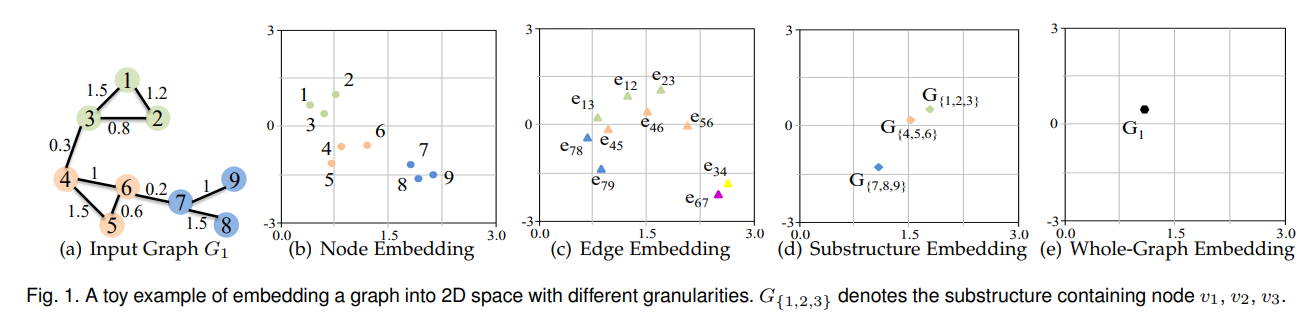

Note: There may not be "semantics" or meaning associated with each number in an embedding. Embeddings can be thought of as a low-dimensional representation of an item in a vector space. Items that are near each other in this embedding space are considered similar to each other in the real world. Embeddings focus on performance, not explainability.

# Shallow Methods


Shallow methods are a type of classic technique in graph embedding that can efficiently process static graphs and extract the underlying structural information of nodes. Although these methods are not as expressive as deep methods, they are simple and efficient, making them very useful in large-scale graph processing.

We use shallow methods for static graphs with sparse features, such as citation networks. However, if we deal with dynamic graphs or graphs containing complex features, we use deep methods (e.g., GCN, GAT), which have high computational costs and require significant computing resources.


Some common shallow methods include:

- Matrix Factorization: Decompose the adjacency matrix or the Laplacian matrix of the graph to generate low-dimensional vectors for nodes. This approach is not suitable for large-scale graphs.

- Random walk-based methods: Generate node neighborhood sequences through random walks, converting the graph embedding task into a sequence modeling problem. Examples include Node2Vec and DeepWalk.

## DeepWalk

DeepWalk [(Perozzi et al., 2014)](https://arxiv.org/pdf/1403.6652) is a widely used vertex representation algorithm. It consists of two main steps: random walks and a Word2Vec model.

First, the random walk generates a sequence of nodes. Starting from node $u$, we conducted $r$ rounds of walks, each of length $l$. During each walk, the next node is randomly selected from the neighbors of the current node. This process results in a node sequence, such as $[u_1, u_2, u_3, u_4]$. The core idea of DeepWalk is to treat the nodes as words and transform the graph structure into a set of sentences.

Next, these generated walks are fed into a Word2Vec model. SkipGram is a widely used word embedding model in NLP, designed to predict neighboring nodes given a node $u$. After training, each node is represented by an embedding vector of fixed size.

The DeepWalk algorithm can be applied to both directed and undirected graphs.

Several Python libraries have integrated the DeepWalk method, including [Karate Club](https://karateclub.readthedocs.io/en/latest/), [PyTorch Geometric (PyG)](https://pytorch-geometric.readthedocs.io/en/latest/#), and the [Deep Graph Library (DGL)](https://docs.dgl.ai/).

In [ ]:
# helper function
def draw_graph(G, node_names={}, node_size=200):
    pos_nodes = nx.spring_layout(G)
    nx.draw(G, pos_nodes, with_labels=True, node_size=node_size, edge_color='gray', arrowsize=10)

    pos_attrs = {}
    for node, coords in pos_nodes.items():
        pos_attrs[node] = (coords[0], coords[1] + 0.08)

    plt.axis('off')
    axis = plt.gca()
    axis.set_xlim([1.2*x for x in axis.get_xlim()])
    axis.set_ylim([1.2*y for y in axis.get_ylim()])
    plt.show()

## Example 1: DeepWalk

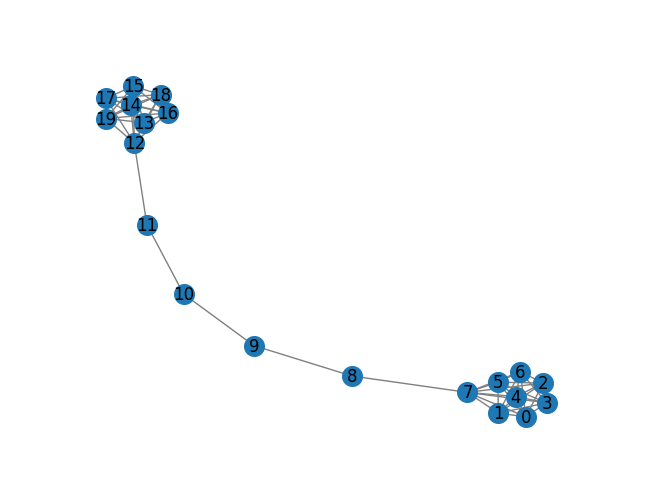

[[0, 7, 0, 1, 0, 3, 7, 2, 6, 7, 4], [0, 3, 5, 1, 5, 0, 5, 6, 1, 4, 6], [0, 4, 7, 5, 4, 3, 5, 2, 0, 7, 0], [0, 3, 4, 2, 4, 3, 5, 1, 5, 1, 2], [0, 2, 0, 2, 3, 1, 2, 5, 4, 2, 5]]


In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity

# Loading a Graph
G = nx.barbell_graph(m1=8, m2=4)
draw_graph(G)

# Random Walks
def random_walk(G, start_node, steps):
    walk = [start_node]
    current_node = start_node
    for _ in range(steps):
        neighbors = list(G.neighbors(current_node))
        if neighbors:
            next_node = random.choice(neighbors)
            walk.append(next_node)
            current_node = next_node
        else:
            break
    return walk

random.seed(2)
steps = 10
num_walks = 5
walks = []

for node in G.nodes():
    for _ in range(num_walks):
        walks.append(random_walk(G, node, steps))

print(walks[:5])

In [ ]:
# Training Word2Vec model
walks_str = [[str(node) for node in walk] for walk in walks] # Converting to string format
model = Word2Vec(walks_str, vector_size=2, window=10, min_count=1, workers=4) # vector_size: Dimensionality of the word vectors
eb = {int(node): model.wv[node] for node in model.wv.index_to_key}
print("Node 0 embedding size:", len(eb[0]))
print(eb[0])

Node 0 embedding size: 2
[0.33140284 0.41408285]


In [ ]:
# Similarity calculation
sim_0_5 = cosine_similarity([model.wv['0']], [model.wv['5']])
print("Similarity between node 0 and node 5:", sim_0_5)
sim_0_10 = cosine_similarity([model.wv['0']], [model.wv['10']])
print("Similarity between node 0 and node 10:", sim_0_10)

sims = model.wv.most_similar('0', topn=3)
print("Top similar nodes to node 0:", sims)

Similarity between node 0 and node 5: [[0.9964563]]
Similarity between node 0 and node 10: [[-0.00103918]]
Top similar nodes to node 0: [('5', 0.9964562654495239), ('18', 0.9025076627731323), ('13', 0.7631807923316956)]


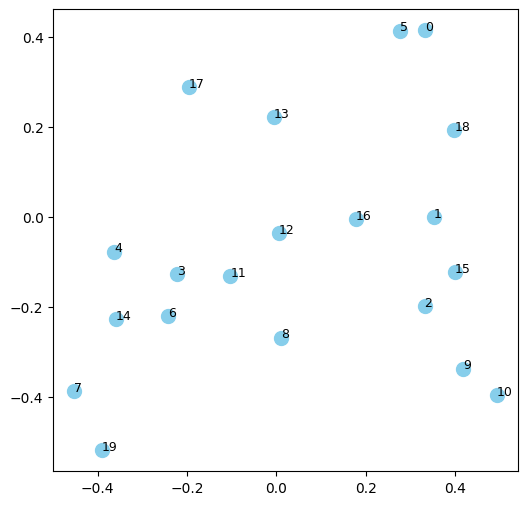

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

for x in G.nodes():
    v = model.wv.get_vector(str(x))
    ax.scatter(v[0],v[1], s=100, color='skyblue')
    ax.annotate(str(x), (v[0],v[1]), fontsize=9)

## Node2Vec 💡


Node2Vec [(Grover & Leskovec, 2016)](https://arxiv.org/abs/1607.00653) is also a method to embed nodes into a lower dimensional vector space. It combines Depth-First Search (DFS) and Breadth-First Search (BFS) to generate random walks and then uses an approach similar to Word2Vec to learn node embeddings.

The difference of Node2Vec and DeepWalk lies in the walking strategy, where Node2Vec employs biased random walks instead of the random walks used in DeepWalk. Node2Vec introduces two parameters `p` and `q`, which allow it to flexibly switch between BFS and DFS.
- BFS prefers to explore nodes directly adjacent to the current node, capturing relationships within the same community. `p` controls the probability of returning to the previous node, which is related to the tendency of local search (similar to BFS).

    - `p>1`: Reduce the probability of returning and encourage exploring the neighbors of the current node.
    - `p<1`: Increase the probability of returning, making the random walk more inclined to stay near the current node.

- DFS prefers to explore nodes far away from the current node and capture relationships across communities. `q` controls the tendency of the random walk to explore neighbors far away from the current node, which is related to the tendency of global search (similar to DFS).
    - `q>1`: Reduce the probability of exploring neighbors far away from the current node.
    - `q<1`: Increase the probability of exploring further away from the current node.

When `p = 1` and `q = 1`, the walk is equivalent to an ordinary random walk without bias.


**Transition Probability**

Suppose the current random walk is starting at node $t$, the current node is $v$, and the goal is to select a neighboring node $x$ of $v$ as the next node.  
The probability of transitioning to a neighboring node $x$ is proportional to the edge weight $w_{vx}$, but also depends on $p$ and $q$:


$$
\pi_{vx} = \frac{\alpha(t, x)}{Z} \cdot w_{vx}
$$

where:
- $\pi_{vx}$ is the transition probability from node $v$ to $x$.
- $w_{vx}$ is the weight of edge $(v, x)$.
- $\alpha(t, x)$ is a control factor related to the parameters $p$ and $q$.
- $Z$ is the normalization constant to ensure the sum of all transition probabilities equals 1.



**Control Factor**

$$
\alpha(t, x) =
\begin{cases}
\frac{1}{p}, & \text{if } d_{tx} = 0 \ (\text{return to node } t) \\
1, & \text{if } d_{tx} = 1 \ (\text{neighboring node)} \\
\frac{1}{q}, & \text{if } d_{tx} = 2 \ (\text{move away from node } t)
\end{cases}
$$

Here $d_{tx}$ is the distance between the target node $x$ and the previous node $t$.

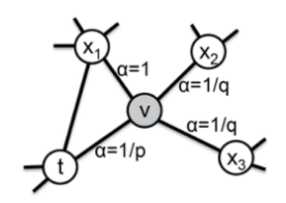


Several Python libraries have integrated the Node2Vec method, including [Karate Club](https://karateclub.readthedocs.io/en/latest/), [PyTorch Geometric (PyG)](https://pytorch-geometric.readthedocs.io/en/latest/#), [StellarGraph](https://stellargraph.readthedocs.io/en/stable/), and the [Deep Graph Library (DGL)](https://docs.dgl.ai/).


## Example 2: Node2Vec

In [ ]:
!pip install node2vec

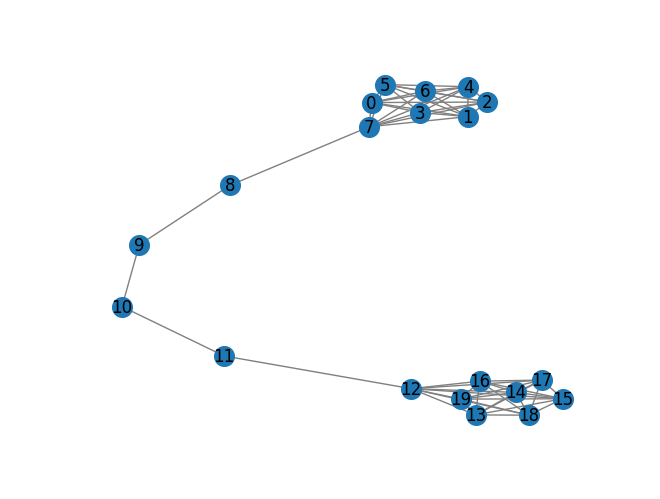

Computing transition probabilities:   0%|          | 0/20 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:00<00:00, 20.41it/s]


In [ ]:
import networkx as nx
from node2vec import Node2Vec
import matplotlib.pyplot as plt

G = nx.barbell_graph(m1=8, m2=4)
draw_graph(G)

node2vec = Node2Vec(G, dimensions=2)
model = node2vec.fit(window=10)

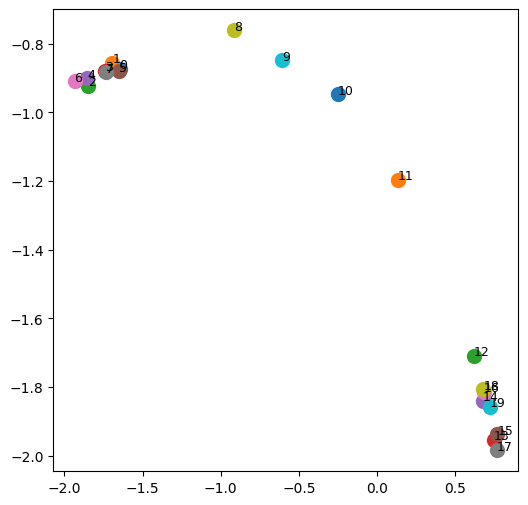

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

for x in G.nodes():
    v = model.wv.get_vector(str(x))
    ax.scatter(v[0],v[1], s=100)
    ax.annotate(str(x), (v[0],v[1]), fontsize=9)

Testing with p=0.5, q=2


Computing transition probabilities:   0%|          | 0/20 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:00<00:00, 50.45it/s]


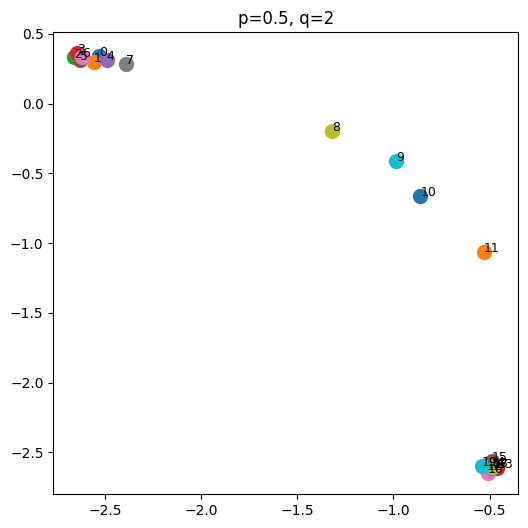

Testing with p=2, q=0.5


Computing transition probabilities:   0%|          | 0/20 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:00<00:00, 72.53it/s]


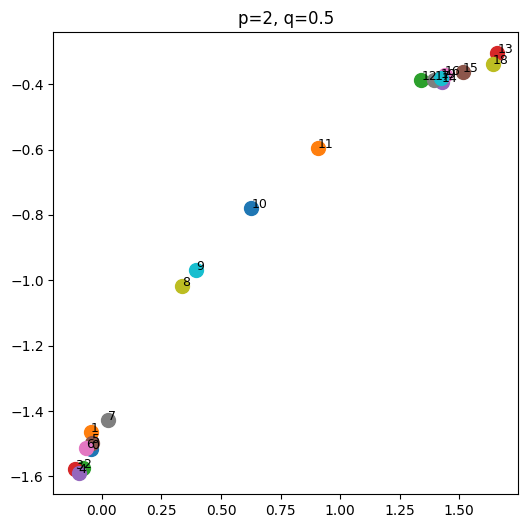

Testing with p=1, q=1


Computing transition probabilities:   0%|          | 0/20 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:00<00:00, 58.31it/s]


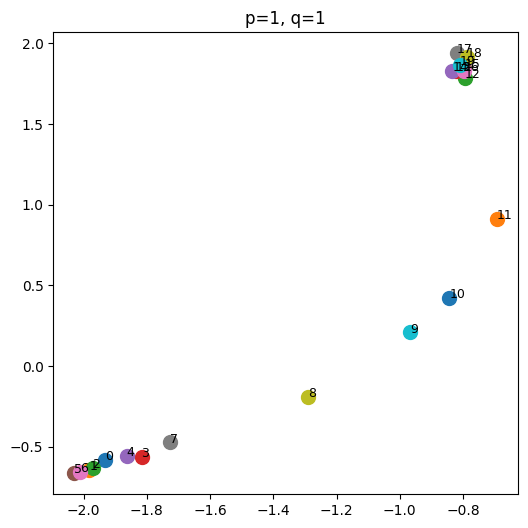

In [ ]:
combinations = [
    (0.5, 2),  # BFS
    (2, 0.5),  # DFS
    (1, 1),    # Deepwalk
]

for p, q in combinations:
    print(f"Testing with p={p}, q={q}")
    node2vec = Node2Vec(G, dimensions=2, p=p, q=q)
    model = node2vec.fit(window=10)

    fig, ax = plt.subplots(figsize=(6, 6))
    for x in G.nodes():
        v = model.wv.get_vector(str(x))
        ax.scatter(v[0], v[1], s=100)
        ax.annotate(str(x), (v[0], v[1]), fontsize=9)
    plt.title(f"p={p}, q={q}")
    plt.show()


## LINE (Large-scale Information Network Embedding)

LINE [(Tang et al., 2015)](https://arxiv.org/abs/1503.03578) is particularly suitable for large-scale graphs because it is computationally efficient and can handle non-dense graphs. It preserves first-order and second-order proximities based on edge weights:

- First-order proximity: Direct connections between nodes. For example, in a social network, if two people are friends, their first-order proximity is high.

- Second-order proximity: Indirect connections between nodes, based on shared neighbors. For example, if two people share many mutual friends, their second-order proximity is high.

Imagine a social network. LINE acts as a tool to "compress" each person into a list of numbers, preserving their direct friendships (first-order proximity) and mutual friendships (second-order proximity). For example, Alice and Bob, as close friends, will have similar vectors, and Alice and Charlie, with many mutual friends, will also have somewhat similar vectors.


## Edge2Vec

Edge2Vec focuses on learning a representation for the relationship (edge) between two nodes.

- Treat each edge as a contextual relationship between two nodes.
- Use random walk strategies similar to Node2Vec to generate paths that include edge relationships.
- Train an embedding model using these paths to create fixed-length vector representations for edges.


In [ ]:
from node2vec.edges import HadamardEmbedder
edges_embs = HadamardEmbedder(keyed_vectors=model.wv)

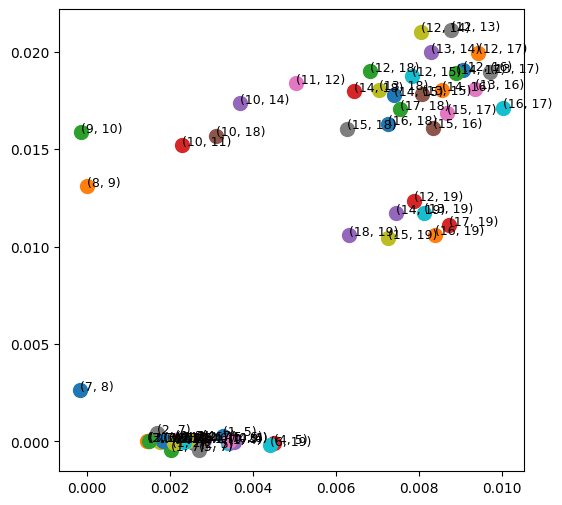

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

for x in G.edges():
    v = edges_embs[(str(x[0]), str(x[1]))]
    ax.scatter(v[0],v[1], s=100)
    ax.annotate(str(x), (v[0],v[1]), fontsize=9)

## Graph2Vec

Graph2Vec aims to generate a fixed-size vector representation for a whole graph. The core idea is inspired by Word2Vec: treating graphs as documents and substructures (e.g., nodes or subgraphs) as words.

- Decompose each graph into multiple substructures (e.g., node features or neighborhoods).
- Encode these substructures to capture their semantic meaning.
- Aggregate all substructure information to form a single representation for the graph.

In [ ]:
# !pip install karateclub

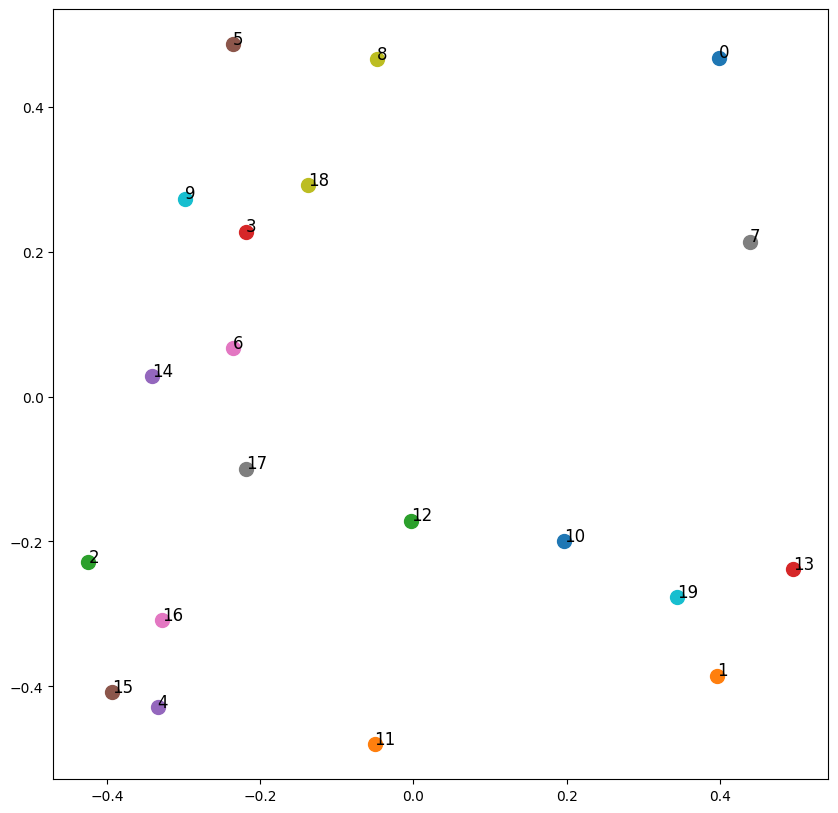

In [ ]:
from karateclub import Graph2Vec

n_graphs = 20

def generate_radom():
    n = random.randint(6, 20)
    k = random.randint(5, n)
    p = random.uniform(0, 1)
    return nx.watts_strogatz_graph(n,k,p), [n,k,p]

Gs = [generate_radom() for x in range(n_graphs)]

model = Graph2Vec(dimensions=2, wl_iterations=10)
model.fit([x[0] for x in Gs])
embeddings = model.get_embedding()

fig, ax = plt.subplots(figsize=(10,10))

for i,vec in enumerate(embeddings):

    ax.scatter(vec[0],vec[1], s=100)
    ax.annotate(str(i), (vec[0],vec[1]), fontsize=12)


# Deep Methods

Deep methods are graph embedding techniques that leverage deep learning to capture complex features, non-linear patterns, and deep relationships within graphs. These methods are particularly powerful for tasks where traditional methods may struggle, such as capturing hierarchical or multi-hop dependencies.


**Deep methods include:**

- GCN-based methods

    Graph Convolutional Networks (GCNs) are one of the most prominent deep learning methods that extend Convolutional Neural Networks (CNNs) from the Euclidean domain to a non-Euclidean domain.

- GAT-based methods
    
    Graph Attention Networks (GATs) introduce a learnable attention mechanism to focus on the most relevant neighbors of a node. By assigning different weights to different neighbors during aggregation, GATs can capture nuanced relationships in the graph.

- GAN-based methods

    Generative Adversarial Networks (GANs) have been adapted for graph embeddings to generate realistic graph structures or improve embeddings.

**When to use deep methods?**
- Graphs are large and complex
- Node/edge features are rich
- Hierarchical or multi-hop dependencies

## GCN: Graph Convolutional Networks 💡

The GCN algorithm borrows concepts from image processing using convolutional neural networks (CNNs). In CNNs, algorithms analyze the pixels surrounding a given pixel to compute the next layer in the network. Images are referred to as being in Euclidean space because the distances between pixels are uniform and predictable. GCN applies a similar approach but in the context of graphs. Instead of pixels, it examines the neighbors of a given node. However, unlike in images, the "distances" between nodes in a graph are non-uniform and unpredictable (non-Euclidean).

**TL;DR: The goal of GCN is to help each node better understand its neighbors.** It identifies a node's neighbors, collects information about them, summarizes the information, and then updates the node's own features.

Example: Recommend new products to users based on relationships between products.

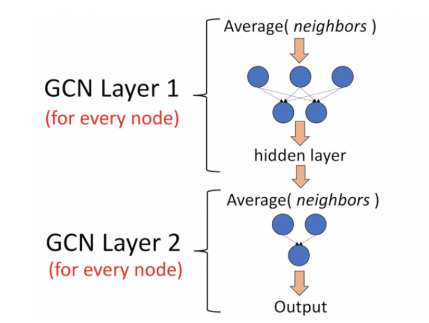

## Example 4: Node classification with GCN

To demonstrate, we make use of the `Cora` dataset, which is a citation network where nodes represent documents.
Each node is described by a 1433-dimensional bag-of-words feature vector.
Two documents are connected if there exists a citation link between them.
The task is to infer the category of each document (7 in total).

In [ ]:
# Loading dataset

from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures

dataset = Planetoid(root='data/Planetoid', name='Cora', transform=NormalizeFeatures())

print()
print(f'Dataset: {dataset}:')
print('======================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

data = dataset[0]  # Get the first graph object.

print()
print(data)


Dataset: Cora():
Number of graphs: 1
Number of features: 1433
Number of classes: 7

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


In [ ]:
print(data.edge_index.shape)
print(data.edge_index.dtype)

torch.Size([2, 10556])
torch.int64


In [ ]:
from torch_geometric.nn import GCNConv
import torch.nn.functional as F # Provides activation functions and other useful functions
from sklearn.manifold import TSNE

def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(8, 8))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set1")
    plt.show()

# GCN model
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        torch.manual_seed(2024)
        # Define two layers of graph convolution
        # The first layer converts the input feature dimension into hidden_channels
        # and the second layer maps hidden_channels to the number of classes
        self.conv1 = GCNConv(dataset.num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu() # ReLU activation function
        x = F.dropout(x, p=0.5, training=self.training) # prevents overfitting
        x = self.conv2(x, edge_index)
        return x

# Instantiate model
model = GCN(hidden_channels=16) # each node in the hidden layer is a 16-dimensional vector
print(model)

GCN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
)


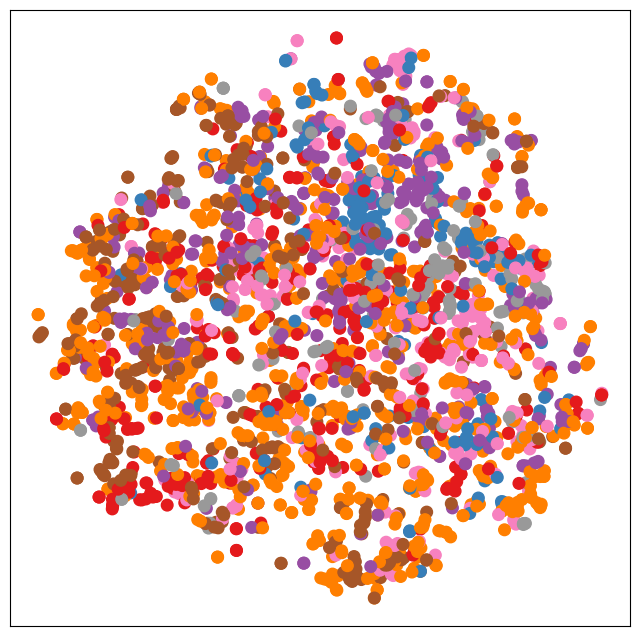

In [ ]:
# Visualize the untrained model
model.eval()
out = model(data.x, data.edge_index)
visualize(out, color=data.y)

In [ ]:
# optimizer: update the parameters of the model to minimize the value of the loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# criterion: define a measure of the difference between the model output and the true label
criterion = torch.nn.CrossEntropyLoss()

def train():
      model.train()
      optimizer.zero_grad()  # Clear gradients
      # We make use of the node features x and the graph connectivity edge_index as input to our GCN model.
      out = model(data.x, data.edge_index)  # Perform a single forward pass
      loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss
      loss.backward()  # Derive gradients
      optimizer.step()  # Update parameters
      return loss

def test():
      model.eval()
      out = model(data.x, data.edge_index)
      pred = out.argmax(dim=1)  # Use the class with highest probability
      test_correct = pred[data.test_mask] == data.y[data.test_mask]  # Check against ground-truth labels
      test_acc = int(test_correct.sum()) / int(data.test_mask.sum())  # Derive ratio of correct predictions
      return test_acc


for epoch in range(1, 101):
    loss = train()
    if epoch % 10 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

Epoch: 010, Loss: 1.8720
Epoch: 020, Loss: 1.7174
Epoch: 030, Loss: 1.5195
Epoch: 040, Loss: 1.3196
Epoch: 050, Loss: 1.1019
Epoch: 060, Loss: 0.9166
Epoch: 070, Loss: 0.7671
Epoch: 080, Loss: 0.6270
Epoch: 090, Loss: 0.5827
Epoch: 100, Loss: 0.5246


In [ ]:
test_acc = test()
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.8160


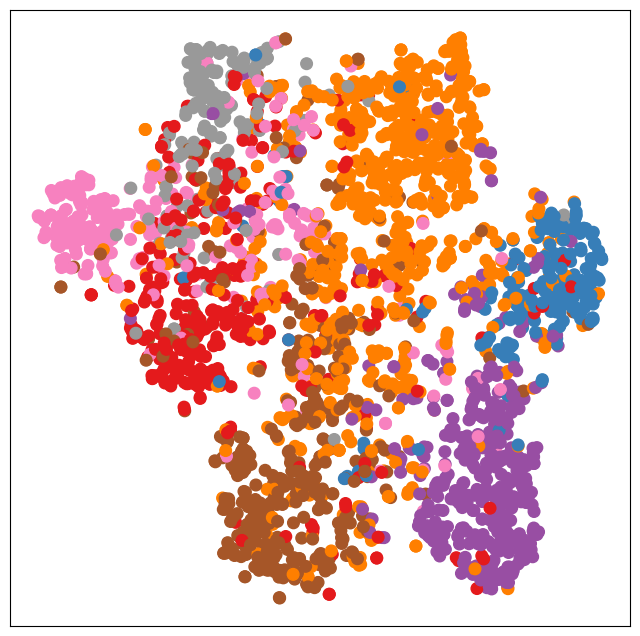

In [ ]:
out = model(data.x, data.edge_index)
visualize(out, color=data.y)

## Example 4: Your Turn! Node classification with GCN

How does a GCN behave when you increase the hidden feature dimensionality or the number of layers? Does increasing the number of layers improve performance? Try modifying the model and observe the results. Hint: You should use a function called `torch.nn.ModuleList`.

In [ ]:
class GCN(torch.nn.Module):
    def __init__(self, num_layers, hidden_channels):
        super().__init__()
        torch.manual_seed(2024)
        self.convs = torch.nn.ModuleList()  # Create a list to hold all layers
        # implement here
        # Input layer: from input features to hidden_channels


        # Hidden layers: from hidden_channels to hidden_channels
        # Exclude input and output layers

        # Output layer: from hidden_channels to the number of classes


    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            # implement here

        return x


Solution:

In [ ]:
class GCN(torch.nn.Module):
    def __init__(self, num_layers, hidden_channels):
        super().__init__()
        torch.manual_seed(2024)
        self.convs = torch.nn.ModuleList()  # Create a list to hold all layers

        # Input layer: from input features to hidden_channels
        self.convs.append(GCNConv(dataset.num_features, hidden_channels))

        # Hidden layers: from hidden_channels to hidden_channels
        for _ in range(num_layers - 2):  # Exclude input and output layers
            self.convs.append(GCNConv(hidden_channels, hidden_channels))

        # Output layer: from hidden_channels to the number of classes
        self.convs.append(GCNConv(hidden_channels, dataset.num_classes))

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:  # Apply ReLU and dropout on all layers except the last
                x = F.relu(x)
                x = F.dropout(x, p=0.5, training=self.training)
        return x

# Instantiate model
num_layers = 3          # Number of layers
hidden_channels = 16    # Number of hidden channels
model = GCN(num_layers, hidden_channels)
print(model)

# Define optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# Training and testing functions remain the same
def train():
    model.train()
    optimizer.zero_grad()  # Clear gradients
    out = model(data.x, data.edge_index)  # Perform a single forward pass
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss
    loss.backward()  # Derive gradients
    optimizer.step()  # Update parameters
    return loss

def test():
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)  # Use the class with the highest probability
    test_correct = pred[data.test_mask] == data.y[data.test_mask]  # Check predictions
    test_acc = int(test_correct.sum()) / int(data.test_mask.sum())  # Compute accuracy
    return test_acc

# Training loop
for epoch in range(1, 101):
    loss = train()
    if epoch % 10 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

# Test the model
test_acc = test()
print(f'Test Accuracy: {test_acc:.4f}')


GCN(
  (convs): ModuleList(
    (0): GCNConv(1433, 16)
    (1): GCNConv(16, 16)
    (2): GCNConv(16, 7)
  )
)
Epoch: 010, Loss: 1.9091
Epoch: 020, Loss: 1.7926
Epoch: 030, Loss: 1.5523
Epoch: 040, Loss: 1.2968
Epoch: 050, Loss: 1.0480
Epoch: 060, Loss: 0.8611
Epoch: 070, Loss: 0.6948
Epoch: 080, Loss: 0.5319
Epoch: 090, Loss: 0.4818
Epoch: 100, Loss: 0.4473
Test Accuracy: 0.7310


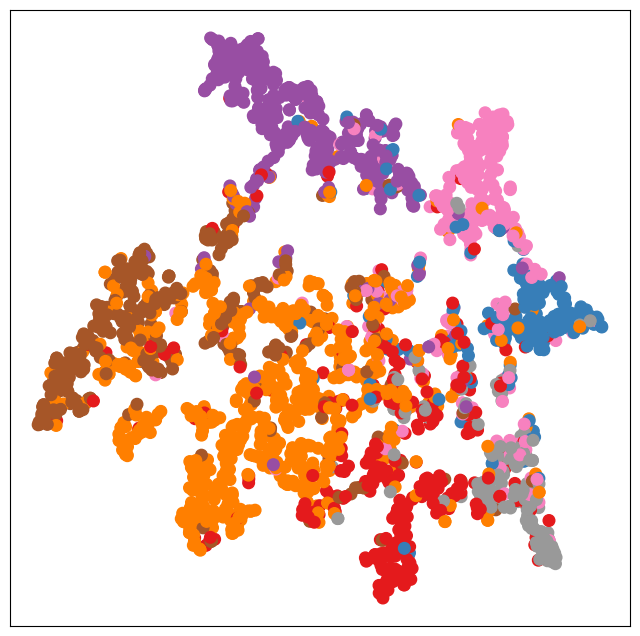

In [ ]:
out = model(data.x, data.edge_index)
visualize(out, color=data.y)

## GraphSAGE

GraphSAGE solves the computational efficiency problem of large graphs by sampling a fixed number of neighbor nodes.

## Example 5: GraphSAGE

In [ ]:
from torch_geometric.nn import SAGEConv

# GraphSAGE Model
class GraphSAGE(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        torch.manual_seed(2024)

        # Define two layers
        self.conv1 = SAGEConv(dataset.num_features, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index):
        # First layer
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)

        # Second layer
        x = self.conv2(x, edge_index)
        return x

# Instantiate model
model = GraphSAGE(hidden_channels=16)
print(model)

# Define optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# Training function
def train():
    model.train()
    optimizer.zero_grad()  # Clear gradients
    out = model(data.x, data.edge_index)  # Forward pass
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute loss
    loss.backward()  # Backward pass
    optimizer.step()  # Update parameters
    return loss

# Testing function
def test():
    model.eval()
    out = model(data.x, data.edge_index)  # Forward pass
    pred = out.argmax(dim=1)  # Get predictions
    correct = pred[data.test_mask] == data.y[data.test_mask]  # Check accuracy
    acc = int(correct.sum()) / int(data.test_mask.sum())
    return acc

# Training loop
for epoch in range(1, 101):
    loss = train()
    if epoch % 10 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

# Test the model
test_acc = test()
print(f'Test Accuracy: {test_acc:.4f}')

GraphSAGE(
  (conv1): SAGEConv(1433, 16, aggr=mean)
  (conv2): SAGEConv(16, 7, aggr=mean)
)
Epoch: 010, Loss: 1.8252
Epoch: 020, Loss: 1.5206
Epoch: 030, Loss: 1.1149
Epoch: 040, Loss: 0.7302
Epoch: 050, Loss: 0.5116
Epoch: 060, Loss: 0.3578
Epoch: 070, Loss: 0.2806
Epoch: 080, Loss: 0.2352
Epoch: 090, Loss: 0.2055
Epoch: 100, Loss: 0.2214
Test Accuracy: 0.8110


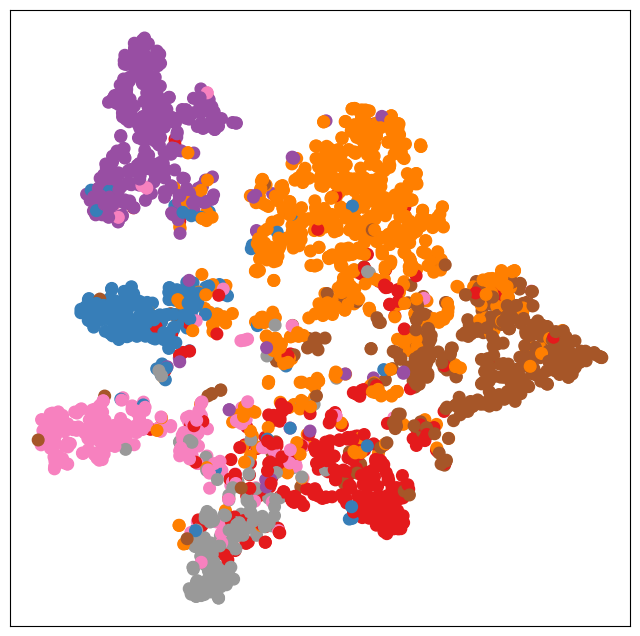

In [ ]:
out = model(data.x, data.edge_index)
visualize(out, color=data.y)

## GAT: Graph Attention Network
GAT is similar to GCN in that it also examines a node's neighbors, but it introduces an attention mechanism to determine which neighbors are more important. It assigns a "weight" (attention score) to each neighbor. Neighbors with higher weights contribute more to the node's updated features, while those with lower weights are less influential. Finally, the weighted neighbor information is aggregated to update the node's features.

Example: Identify the most relevant information to answer a question in a knowledge graph.



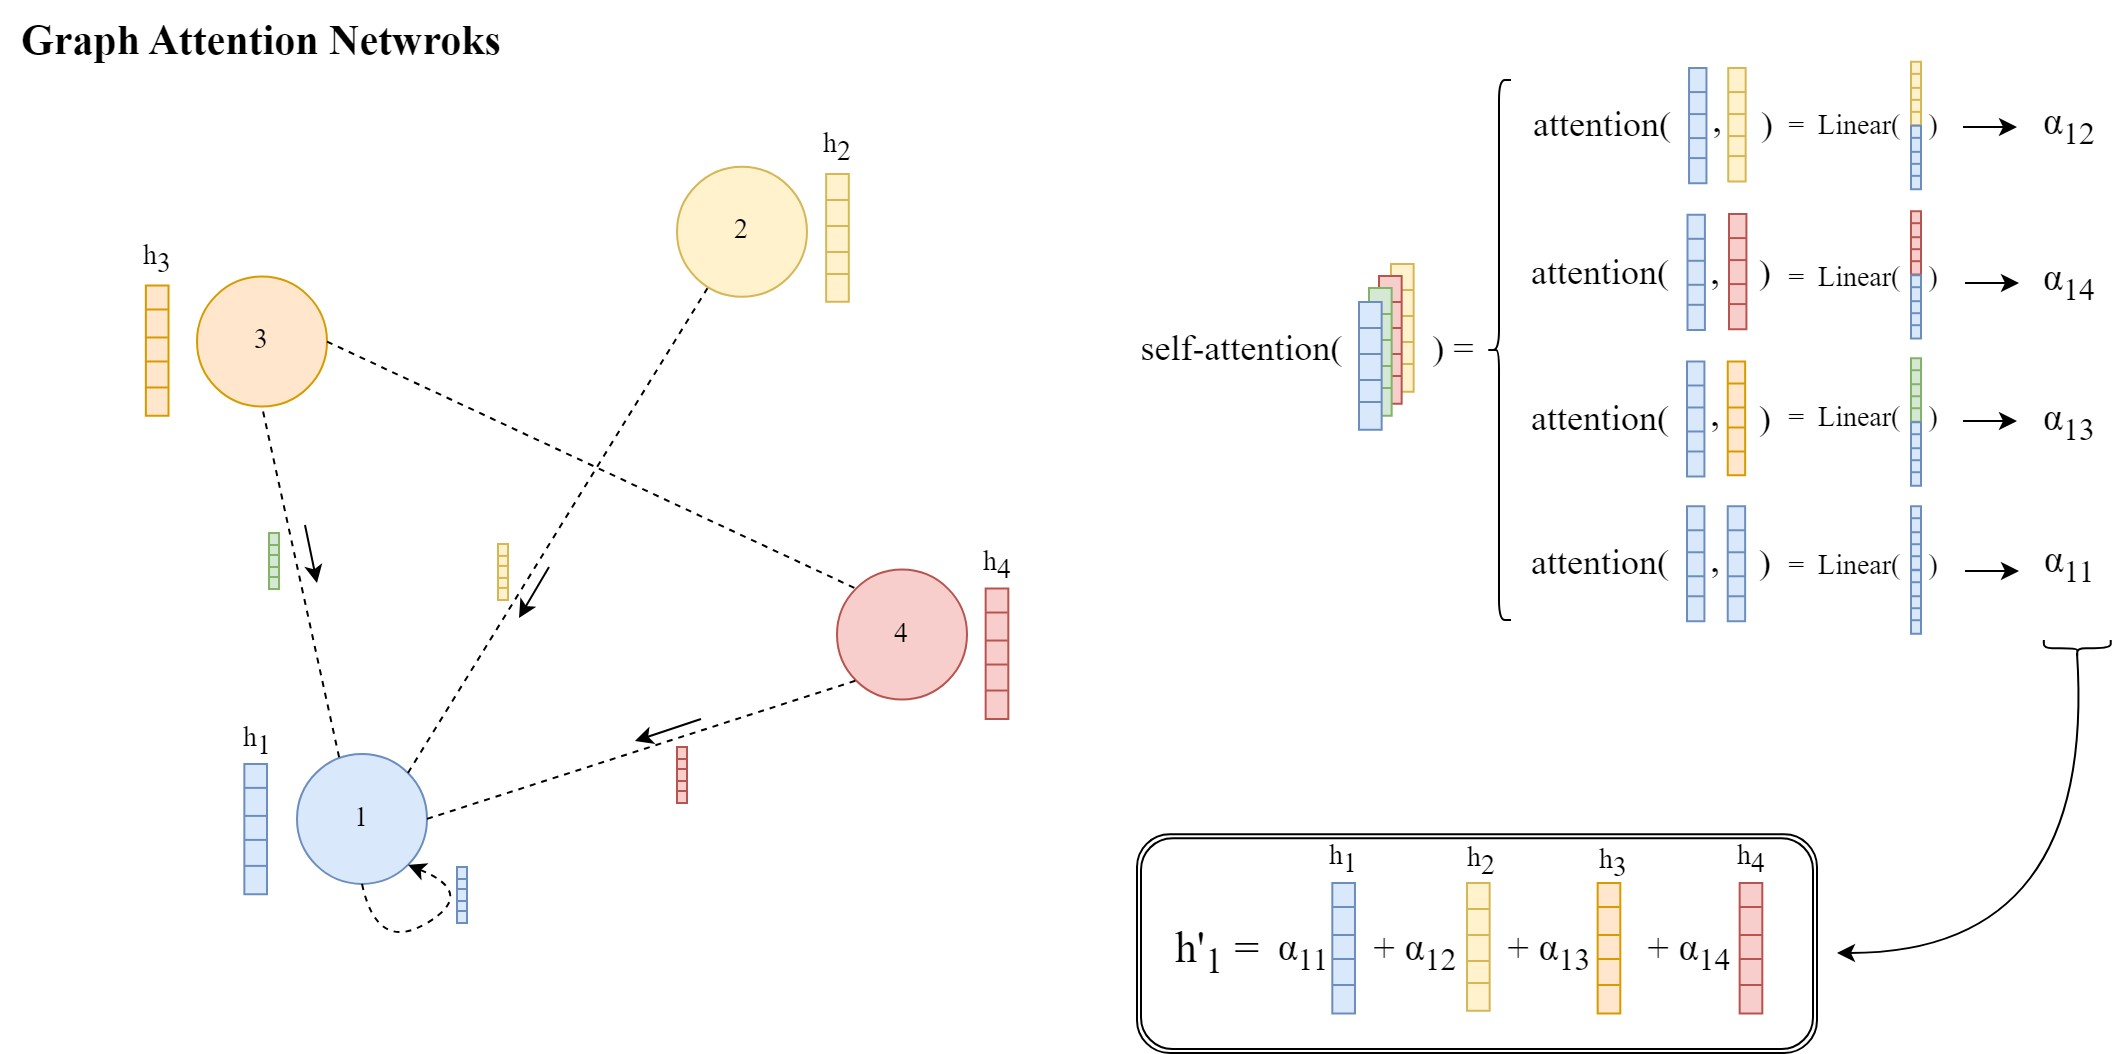

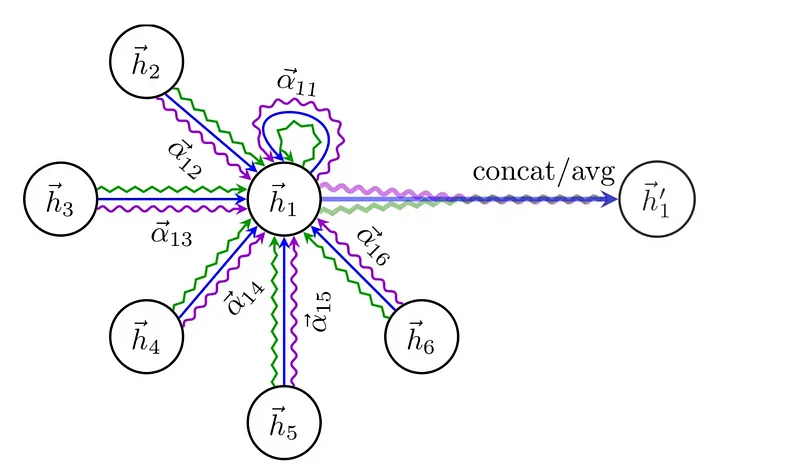

The arrows shows different attention heads. In intermediate layers, we concat them. In Final Prediction Layer, we average them.

## Example 6: Your Turn! GAT

Try to write a 2-layer GAT model that makes use of 8 attention heads in the first layer and 1 attention head in the second layer, uses a dropout ratio of 0.6 inside and outside each GATConv call, and uses a hidden_channels dimensions of 8 per head.

In [ ]:
from torch_geometric.nn import GATConv

class GAT(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        torch.manual_seed(2024)
        # GATConv with 8 attention heads in the first layer
        self.conv1 = GATConv(...)

        # GATConv with 1 attention head in the second layer
        self.conv2 = GATConv(...)

    def forward(self, x, edge_index):
        # First GAT layer
        x = self.conv1(x, edge_index)
        x = F.dropout(x, p=0.6, training=self.training)
        x = F.relu(x)

        # Second GAT layer
        x = self.conv2(x, edge_index)
        x = F.dropout(x, p=0.6, training=self.training)
        return x


Solution:

In [ ]:
from torch_geometric.nn import GATConv

class GAT(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        torch.manual_seed(2024)
        # GATConv with 8 attention heads in the first layer
        # The purpose of multi-head attention is to allow the model to learn different attention distributions from multiple subspaces
        self.conv1 = GATConv(
            in_channels=dataset.num_features,
            out_channels=hidden_channels,
            heads=8,
            dropout=0.6
        )
        # GATConv with 1 attention head in the second layer
        self.conv2 = GATConv(
            in_channels=hidden_channels * 8,  # Multiply by the number of heads
            out_channels=dataset.num_classes,
            heads=1,
            dropout=0.6
        )

    def forward(self, x, edge_index):
        # First GAT layer
        x = self.conv1(x, edge_index)
        x = F.dropout(x, p=0.6, training=self.training)
        x = F.relu(x)

        # Second GAT layer
        x = self.conv2(x, edge_index)
        x = F.dropout(x, p=0.6, training=self.training)
        return x


In [ ]:
model = GAT(hidden_channels=8)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

def train():
      model.train()
      optimizer.zero_grad()  # Clear gradients.
      out = model(data.x, data.edge_index)  # Perform a single forward pass.
      loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes.
      loss.backward()  # Derive gradients.
      optimizer.step()  # Update parameters based on gradients.
      return loss

def test(mask):
      model.eval()
      out = model(data.x, data.edge_index)
      pred = out.argmax(dim=1)  # Use the class with highest probability.
      correct = pred[mask] == data.y[mask]  # Check against ground-truth labels.
      acc = int(correct.sum()) / int(mask.sum())  # Derive ratio of correct predictions.
      return acc


for epoch in range(1, 201):
    loss = train()
    if epoch % 20 == 0:
        val_acc = test(data.val_mask)
        test_acc = test(data.test_mask)
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val: {val_acc:.4f}, Test: {test_acc:.4f}')



Epoch: 020, Loss: 1.8249, Val: 0.5720, Test: 0.5820
Epoch: 040, Loss: 1.5992, Val: 0.7780, Test: 0.7900
Epoch: 060, Loss: 1.4661, Val: 0.7820, Test: 0.8010
Epoch: 080, Loss: 1.4005, Val: 0.7960, Test: 0.8190
Epoch: 100, Loss: 1.3973, Val: 0.7940, Test: 0.8120
Epoch: 120, Loss: 1.3886, Val: 0.8000, Test: 0.8200
Epoch: 140, Loss: 1.3063, Val: 0.7980, Test: 0.8100
Epoch: 160, Loss: 1.4378, Val: 0.7960, Test: 0.8190
Epoch: 180, Loss: 1.3235, Val: 0.8000, Test: 0.8080
Epoch: 200, Loss: 1.3862, Val: 0.8000, Test: 0.8200


## GAN: Generative Adversarial Network
GANs consist of two components: a generator and a discriminator. The generator attempts to create fake data (e.g., synthetic images). The discriminator tries to distinguish between real and fake data. Through this adversarial process, the generator improves over time, becoming skilled at fooling the discriminator and generating more realistic data.

Example: Generate realistic fake images or synthetic data for analysis.

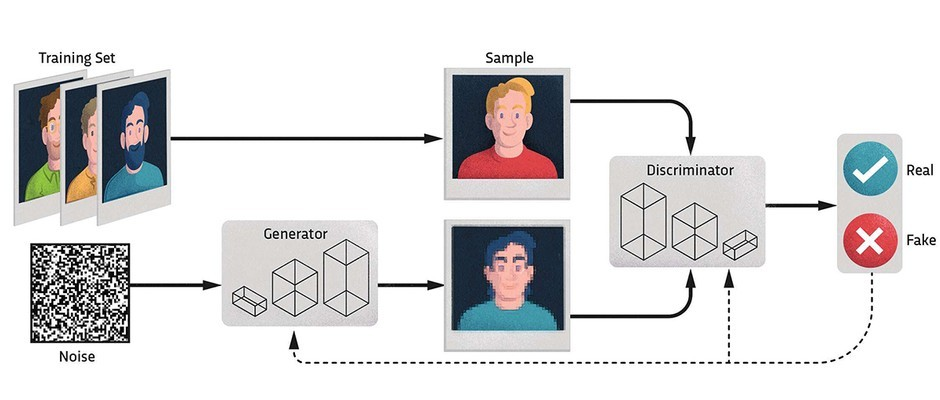

## Example 7: GraphGAN

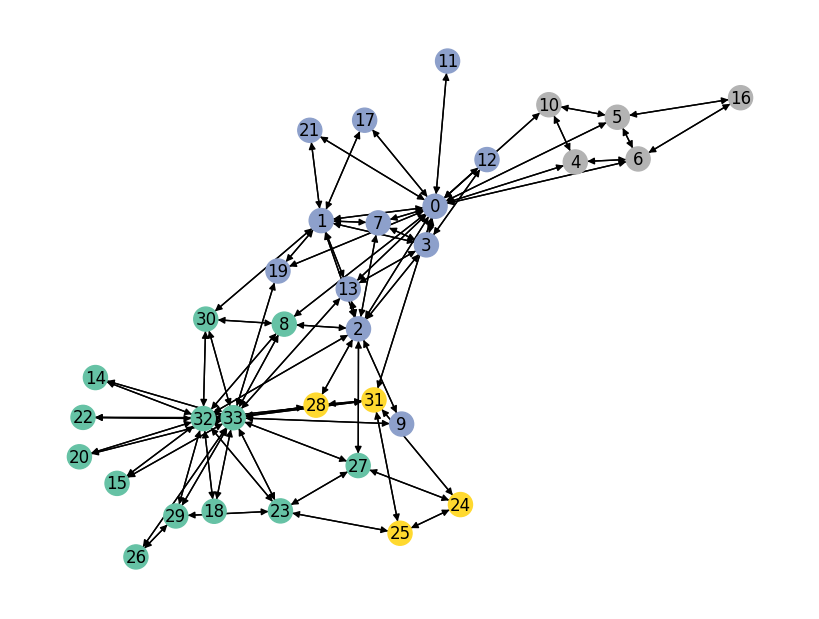

Epoch 000 | D Loss: 1.4196 | G Loss: 0.7008
Epoch 020 | D Loss: 1.3909 | G Loss: 0.7109
Epoch 040 | D Loss: 1.3660 | G Loss: 0.7212
Epoch 060 | D Loss: 1.3723 | G Loss: 0.7239
Epoch 080 | D Loss: 1.3754 | G Loss: 0.7007
Epoch 100 | D Loss: 1.3797 | G Loss: 0.6861
Epoch 120 | D Loss: 1.3984 | G Loss: 0.6950
Epoch 140 | D Loss: 1.3970 | G Loss: 0.7114
Epoch 160 | D Loss: 1.3582 | G Loss: 0.7329
Epoch 180 | D Loss: 1.3546 | G Loss: 0.7322


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.datasets import KarateClub
from torch_geometric.utils import to_networkx

# Load dataset
dataset = KarateClub()
data = dataset[0]
graph = to_networkx(data)

# Visualize the graph
def visualize_graph(graph, node_color):
    plt.figure(figsize=(8, 6))
    nx.draw(graph, with_labels=True, node_color=node_color, cmap="Set2")
    plt.show()

visualize_graph(graph, data.y)

# Generator
class Generator(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):
        z = torch.relu(self.fc1(z))
        z = torch.tanh(self.fc2(z))
        return z

# Discriminator
class Discriminator(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

# Parameters
input_dim = data.num_features  # Real node features' dimensionality
hidden_dim = 16
output_dim = 16
z_dim = 16  # Noise input dimensionality
lr = 0.001

# Initialize models
generator = Generator(z_dim, hidden_dim, output_dim)
discriminator = Discriminator(output_dim, hidden_dim)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=lr)
d_optimizer = optim.Adam(discriminator.parameters(), lr=lr)

# Training loop
num_epochs = 200
for epoch in range(num_epochs):
    # Step 1: Train Discriminator
    discriminator.train()
    real_nodes = data.x
    if real_nodes.shape[1] != output_dim:  # Adjust real nodes' dimensionality if needed
        real_nodes = nn.Linear(real_nodes.shape[1], output_dim)(real_nodes)
    z = torch.randn(real_nodes.size(0), z_dim)  # Random noise
    fake_nodes = generator(z)

    real_scores = discriminator(real_nodes)
    fake_scores = discriminator(fake_nodes.detach())

    d_loss = -torch.mean(torch.log(real_scores) + torch.log(1 - fake_scores))
    d_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()

    # Step 2: Train Generator
    generator.train()
    fake_scores = discriminator(fake_nodes)
    g_loss = -torch.mean(torch.log(fake_scores))

    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

    # Logging
    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")


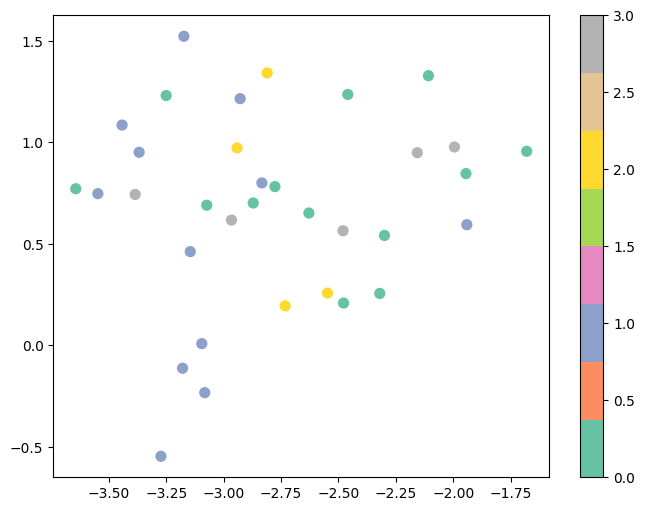

In [ ]:
generator.eval()
z = torch.randn(data.x.size(0), z_dim)
node_embeddings = generator(z).detach()

tsne = TSNE(n_components=2)
embeddings_2d = tsne.fit_transform(node_embeddings.numpy())

plt.figure(figsize=(8, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=data.y.numpy(), cmap="Set2", s=50)
plt.colorbar()
plt.show()

## Comparison of Shallow and Deep Methods

Take the classic Karate Club network as an example.

Node2Vec effectively captures the structural features of graphs (such as the community formed by members with the same opinions in a club). At the same time, it relies only on the topology of the graph and does not require node features. Even if the nodes have no additional attribute information, Node2Vec can still generate meaningful embeddings.

If the nodes have attributes (such as the member's age, position, etc.), Node2Vec cannot directly use this information. GCN combines graph structure and node attributes through its message-passing mechanism, making it ideal for tasks like node classification when node features are present. However, GCN can be computationally expensive for large graphs, whereas Node2Vec is more efficient in such scenarios.

# Evaluation

The evaluation of network embeddings is mainly divided into two categories: intrinsic evaluation and extrinsic evaluation.

- Intrinsic evaluation: Assesses whether the embeddings can effectively preserve the structural characteristics of the network, such as node similarity, community structure, and global or local topological information. Common metrics include reconstruction loss, similarity, among others.

- Extrinsic evaluation: Measures the performance of embeddings on downstream tasks, such as node classification, link prediction, or clustering. Common metrics include:
    - Node classification: Accuracy, F1 score, Precision, Recall, ROC-AUC
    - Link prediction: Accuracy, F1 score, Precision, Recall, AUC (Area Under the Curve), AP (Average Precision)


## Example 8: Calculate the metrics of node classification task

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Set the GCN model to evaluation mode and extract node embeddings
model.eval()
node_embeddings = model(data.x, data.edge_index).detach()

# Split the dataset into training and testing sets
train_mask = data.train_mask.numpy()  # Boolean mask
test_mask = data.test_mask.numpy()  # Boolean mask
y_train = data.y[train_mask].numpy() # Labels
y_test = data.y[test_mask].numpy() # Labels

# Train a logistic regression classifier
clf = LogisticRegression(max_iter=1000)
clf.fit(node_embeddings[train_mask].numpy(), y_train) # Fit the classifier on training data

# Predict on the testing set
y_pred = clf.predict(node_embeddings[test_mask].numpy()) # Predicted labels
y_prob = clf.predict_proba(node_embeddings[test_mask].numpy())  # Predicted probabilities for ROC-AUC

# Binarize labels for multi-class ROC-AUC
y_test_bin = label_binarize(y_test, classes=np.unique(data.y.numpy()))

#  Compute evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='weighted')


print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")


Accuracy: 0.8090
F1 Score: 0.8107
Precision: 0.8210
Recall: 0.8090
ROC-AUC: 0.9629


# Dynamic Network Embedding

## Why static embeddings are not enough?

Most networks in the real world are dynamic and continually change over time, similar to removing or adding nodes, edges, etc. For instance, in social networks, new users are frequently added and old users are removed. Furthermore, new links may be added while some previous links may be removed between the users. Additionally, user profile information is updated and changed, consequently changing the graph structure over time. To embed dynamic graphs, special methods should be used that can effectively accommodate these changes.

## Dynamic Techniques

- Incremental Updates

    Initially, the static network is embedded. When the network changes (such as the addition or removal of nodes/edges), only the embedding of the affected part is updated without recalculating the embedding of the entire network.

     - DynamicTriad [(Zhou et al., 2018)](https://dl.acm.org/doi/10.5555/3504035.3504106)


- Time-Series Modeling
    The dynamic changes of the network are regarded as a time series problem, and the temporal dependencies of nodes/edges are captured by learning the network state at each time point.

    - DynGEM [(Goyal et al., 2018)](https://arxiv.org/abs/1805.11273)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.datasets import KarateClub
from torch_geometric.utils import to_networkx, train_test_split_edges
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

Time Step 1/4
Loss: 4.9837 (Edge Loss: 1.8266, Triadic Loss: 31.5710)


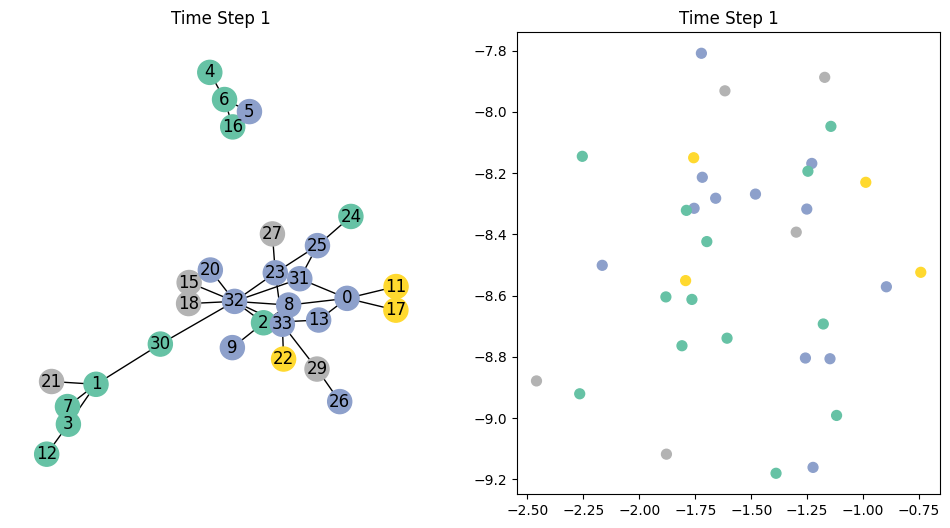

Time Step 2/4
Loss: 4.6561 (Edge Loss: 1.8766, Triadic Loss: 27.7948)


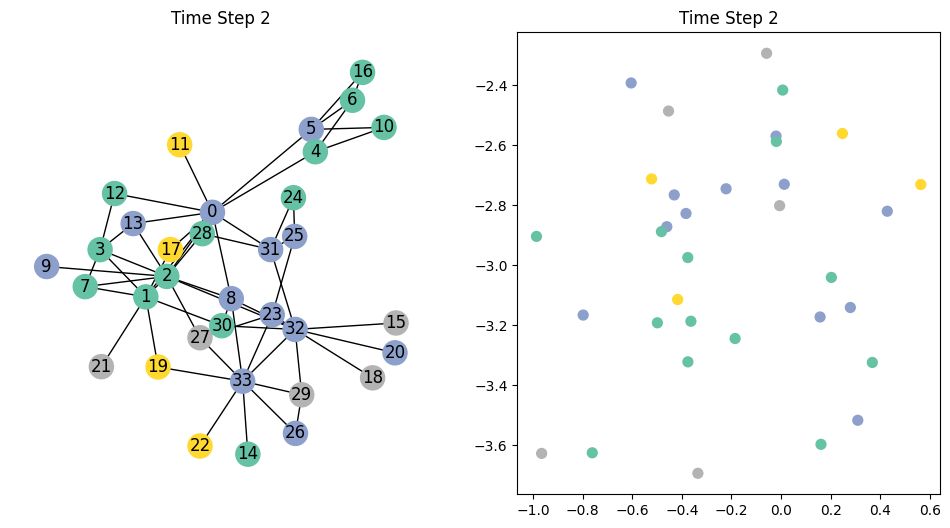

Time Step 3/4
Loss: 4.1508 (Edge Loss: 1.4290, Triadic Loss: 27.2185)


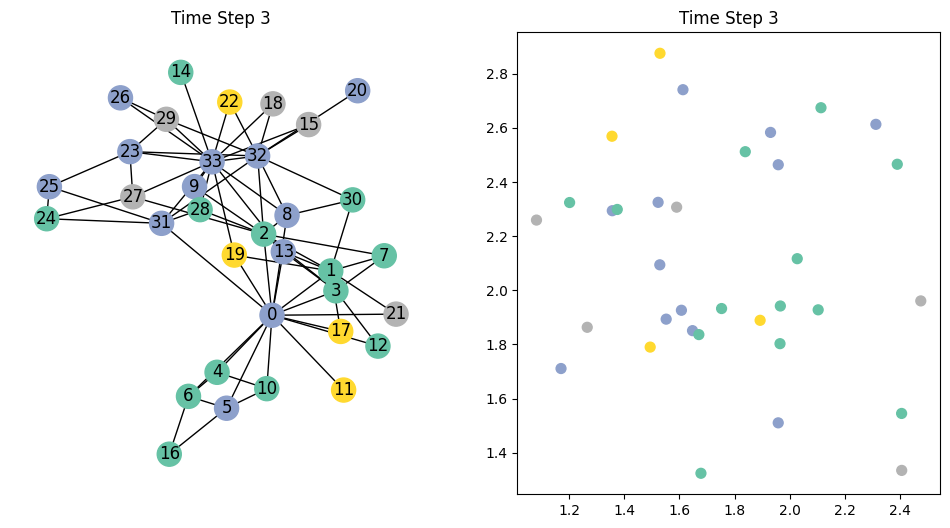

Time Step 4/4
Loss: 4.2916 (Edge Loss: 1.5878, Triadic Loss: 27.0382)


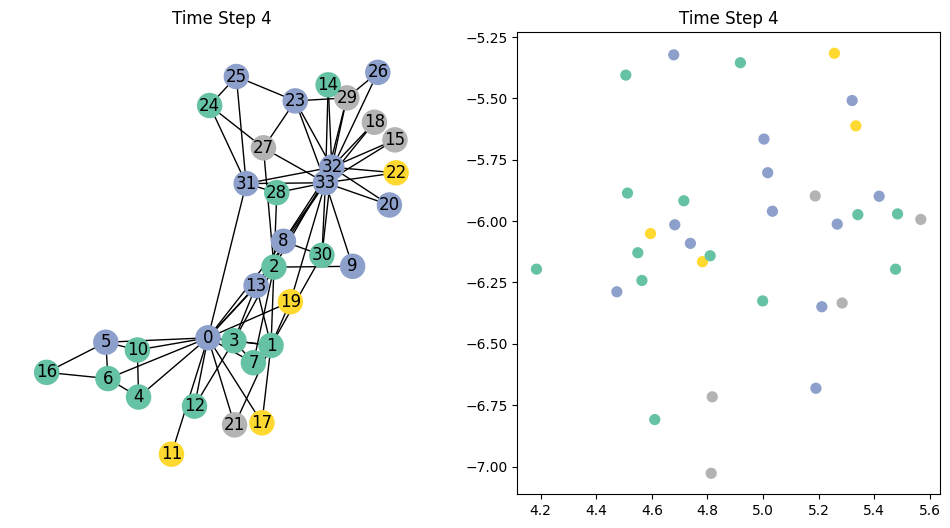

In [ ]:
# Load Karate Club dataset
dataset = KarateClub()
data = dataset[0]

# Split the graph into time steps (simulate dynamics by incrementally adding edges)
edge_index = data.edge_index.numpy()
num_edges = edge_index.shape[1]
time_steps = 4
edges_per_step = num_edges // time_steps

# Shuffle edges and divide into time steps
np.random.seed(42)
shuffled_indices = np.random.permutation(num_edges)
edge_index = edge_index[:, shuffled_indices]
edge_splits = [edge_index[:, i * edges_per_step:(i + 1) * edges_per_step] for i in range(time_steps)]

# Define DynamicTriad model
class DynamicTriad(nn.Module):
    def __init__(self, num_nodes, embedding_dim):
        super(DynamicTriad, self).__init__()
        self.embedding = nn.Embedding(num_nodes, embedding_dim)

    def forward(self, edge_index):
        src, dst = edge_index
        src_embed = self.embedding(src)
        dst_embed = self.embedding(dst)
        scores = (src_embed * dst_embed).sum(dim=1)  # Inner product as similarity score
        return scores

    def triadic_closure_loss(self, edge_index):
        src, dst = edge_index
        src_embed = self.embedding(src)
        dst_embed = self.embedding(dst)
        # Triadic closure loss approximation
        return ((src_embed - dst_embed).norm(dim=1) ** 2).mean()

# Initialize model and optimizer
num_nodes = data.num_nodes
embedding_dim = 16
model = DynamicTriad(num_nodes, embedding_dim)
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Loss function (binary cross-entropy for edge prediction)
criterion = nn.BCEWithLogitsLoss()

# Visualize graph dynamically
def visualize_dynamic_graph(graph, node_embeddings, step, labels):
    plt.figure(figsize=(12, 6))

    # Subplot 1: Graph structure
    plt.subplot(1, 2, 1)
    pos = nx.spring_layout(graph)
    nx.draw(graph, pos, with_labels=True, node_color=labels[:len(graph.nodes)], cmap="Set2", node_size=300)
    plt.title(f"Time Step {step}")

    # Subplot 2: Node embeddings
    plt.subplot(1, 2, 2)
    tsne = TSNE(n_components=2, random_state=42)
    embeddings_2d = tsne.fit_transform(node_embeddings)
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels[:len(embeddings_2d)], cmap="Set2", s=50)
    plt.title(f"Time Step {step}")

    plt.show()

# Training loop for dynamic embedding
graph = nx.Graph()
for t in range(time_steps):
    print(f"Time Step {t+1}/{time_steps}")

    # Get edges for the current time step
    edges = torch.tensor(edge_splits[t], dtype=torch.long)

    # Add edges to the graph
    graph.add_edges_from(edges.T.numpy())

    # Create negative samples (randomly generate non-existent edges)
    neg_edges = torch.randint(0, num_nodes, edges.shape, dtype=torch.long)

    # Combine positive and negative edges
    edge_index = torch.cat([edges, neg_edges], dim=1)
    labels = torch.cat([torch.ones(edges.shape[1]), torch.zeros(neg_edges.shape[1])])

    # Train the model
    model.train()
    optimizer.zero_grad()
    predictions = model(edge_index)
    edge_loss = criterion(predictions, labels)
    triadic_loss = model.triadic_closure_loss(edges)
    loss = edge_loss + 0.1 * triadic_loss  # Combine edge prediction and triadic closure loss
    loss.backward()
    optimizer.step()

    print(f"Loss: {loss.item():.4f} (Edge Loss: {edge_loss.item():.4f}, Triadic Loss: {triadic_loss.item():.4f})")

    # Visualize graph and embeddings
    model.eval()
    node_embeddings = model.embedding.weight.detach().numpy()
    visualize_dynamic_graph(graph, node_embeddings, t + 1, data.y.numpy())

Time Step 1/4
Loss: 0.2495


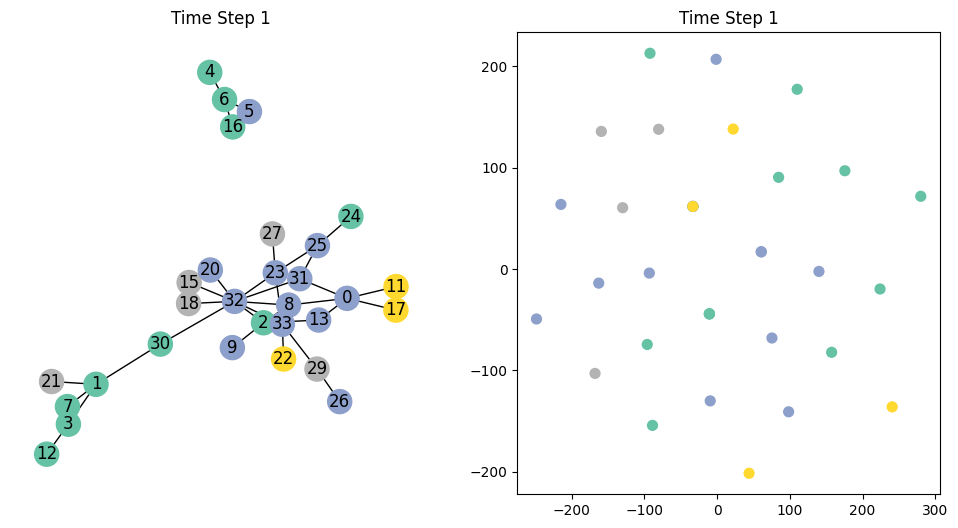

Time Step 2/4
Loss: 0.2403


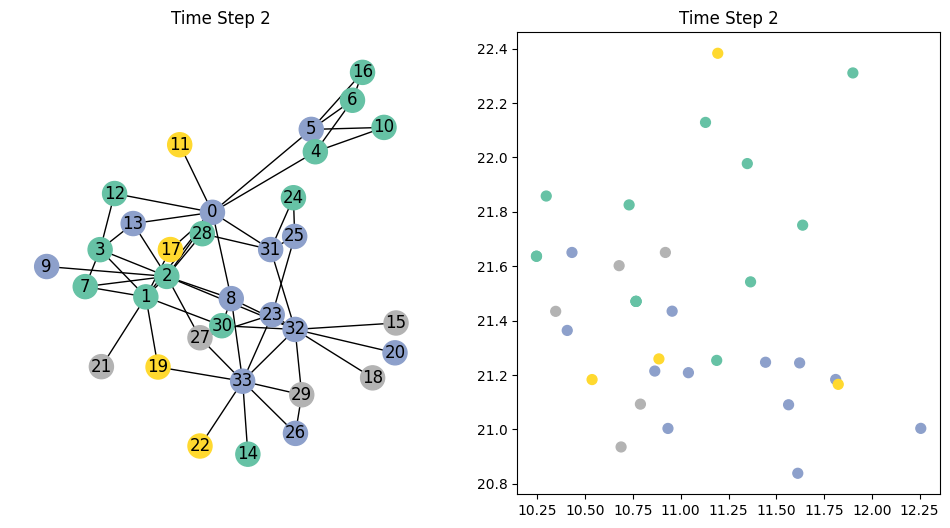

Time Step 3/4
Loss: 0.2309


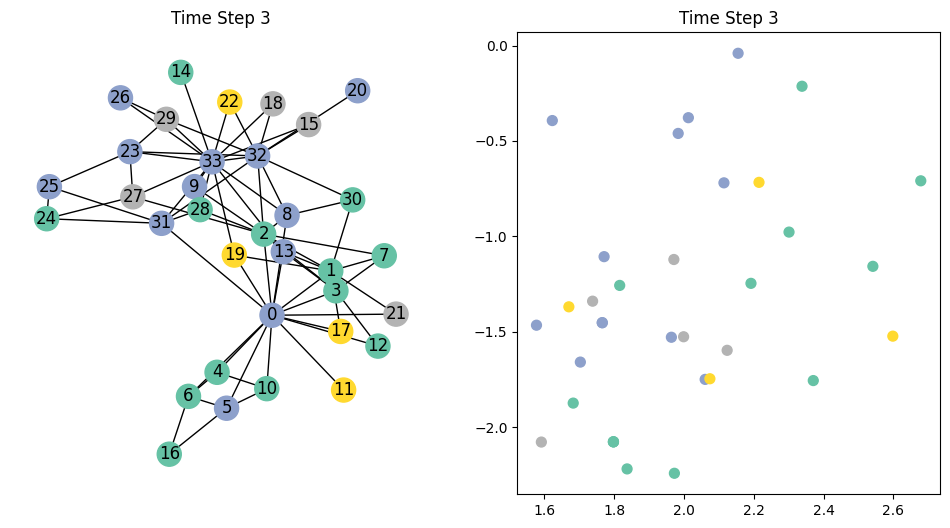

Time Step 4/4
Loss: 0.2193


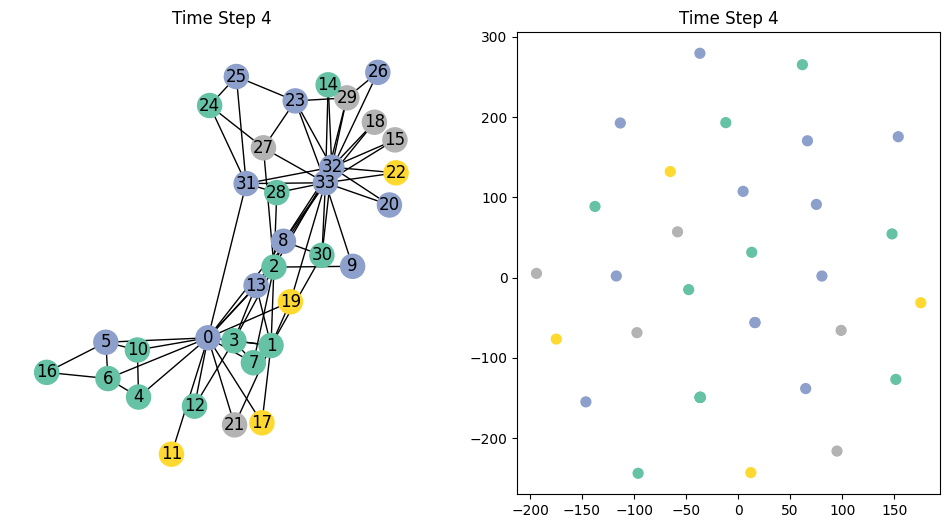

In [ ]:
# Load Karate Club dataset
dataset = KarateClub()
data = dataset[0]

# Split the graph into time steps (simulate dynamics by incrementally adding edges)
edge_index = data.edge_index.numpy()
num_edges = edge_index.shape[1]
time_steps = 4
edges_per_step = num_edges // time_steps

# Shuffle edges and divide into time steps
np.random.seed(42)
shuffled_indices = np.random.permutation(num_edges)
edge_index = edge_index[:, shuffled_indices]
edge_splits = [edge_index[:, i * edges_per_step:(i + 1) * edges_per_step] for i in range(time_steps)]

# Define DynGEM model
class DynGEM(nn.Module):
    def __init__(self, num_nodes, embedding_dim, hidden_dims):
        super(DynGEM, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(num_nodes, hidden_dims[0]),
            nn.ReLU(),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(hidden_dims[1], embedding_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(hidden_dims[1], hidden_dims[0]),
            nn.ReLU(),
            nn.Linear(hidden_dims[0], num_nodes),
            nn.Sigmoid()
        )

    def forward(self, adjacency_matrix):
        embedding = self.encoder(adjacency_matrix)
        reconstructed = self.decoder(embedding)
        return embedding, reconstructed

# Initialize model and optimizer
num_nodes = data.num_nodes
embedding_dim = 16
hidden_dims = [64, 32]
model = DynGEM(num_nodes, embedding_dim, hidden_dims)
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Loss function (Mean Squared Error for reconstruction)
criterion = nn.MSELoss()

# Visualize graph dynamically
def visualize_dynamic_graph(graph, node_embeddings, step, labels):
    plt.figure(figsize=(12, 6))

    # Subplot 1: Graph structure
    plt.subplot(1, 2, 1)
    pos = nx.spring_layout(graph)
    nx.draw(graph, pos, with_labels=True, node_color=labels[:len(graph.nodes)], cmap="Set2", node_size=300)
    plt.title(f"Time Step {step}")

    # Subplot 2: Node embeddings
    plt.subplot(1, 2, 2)
    tsne = TSNE(n_components=2, random_state=42)
    embeddings_2d = tsne.fit_transform(node_embeddings)
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels[:len(embeddings_2d)], cmap="Set2", s=50)
    plt.title(f"Time Step {step}")

    plt.show()

# Training loop for DynGEM
graph = nx.Graph()
adjacency_matrix = torch.zeros((num_nodes, num_nodes))
for t in range(time_steps):
    print(f"Time Step {t+1}/{time_steps}")

    # Get edges for the current time step
    edges = torch.tensor(edge_splits[t], dtype=torch.long)

    # Add edges to the graph
    graph.add_edges_from(edges.T.numpy())
    for edge in edges.T.numpy():
        adjacency_matrix[edge[0], edge[1]] = 1
        adjacency_matrix[edge[1], edge[0]] = 1

    # Train the model
    model.train()
    optimizer.zero_grad()
    embedding, reconstructed = model(adjacency_matrix)
    loss = criterion(reconstructed, adjacency_matrix)
    loss.backward()
    optimizer.step()

    print(f"Loss: {loss.item():.4f}")

    # Visualize graph and embeddings
    model.eval()
    with torch.no_grad():
        node_embeddings, _ = model(adjacency_matrix)
    visualize_dynamic_graph(graph, node_embeddings.numpy(), t + 1, data.y.numpy())


# References and further resources

1. Noori, A., Balafar, M.A., Bouyer, A. et al. Review of heterogeneous graph embedding methods based on deep learning techniques and comparing their efficiency in node classification. Soc. Netw. Anal. Min. 14, 17 (2024).

2. Cai, H., Zheng, V. W., & Chang, K. C. C. (2018). A comprehensive survey of graph embedding: Problems, techniques, and applications. IEEE transactions on knowledge and data engineering, 30(9), 1616-1637.

3. Xu, M. (2021). Understanding graph embedding methods and their applications. SIAM Review, 63(4), 825-853.

4. Perozzi, B., Al-Rfou, R., & Skiena, S. (2014, August). Deepwalk: Online learning of social representations. In Proceedings of the 20th ACM SIGKDD international conference on Knowledge discovery and data mining (pp. 701-710).

5. Grover, A., & Leskovec, J. (2016, August). node2vec: Scalable feature learning for networks. In Proceedings of the 22nd ACM SIGKDD international conference on Knowledge discovery and data mining (pp. 855-864).

6. Tang, J., Qu, M., Wang, M., Zhang, M., Yan, J., & Mei, Q. (2015, May). Line: Large-scale information network embedding. In Proceedings of the 24th international conference on world wide web (pp. 1067-1077).

7. Gao, Z., Fu, G., Ouyang, C., Tsutsui, S., Liu, X., Yang, J., ... & Yu, Q. (2019). edge2vec: Representation learning using edge semantics for biomedical knowledge discovery. BMC bioinformatics, 20, 1-15.

8. Narayanan, A., Chandramohan, M., Venkatesan, R., Chen, L., Liu, Y., & Jaiswal, S. (2017). graph2vec: Learning distributed representations of graphs. arXiv preprint arXiv:1707.05005.

9. Grohe, M. (2020, June). word2vec, node2vec, graph2vec, x2vec: Towards a theory of vector embeddings of structured data. In Proceedings of the 39th ACM SIGMOD-SIGACT-SIGAI Symposium on Principles of Database Systems (pp. 1-16).

10. Liu, J., Ong, G. P., & Chen, X. (2020). GraphSAGE-based traffic speed forecasting for segment network with sparse data. IEEE Transactions on Intelligent Transportation Systems, 23(3), 1755-1766.

11. Wang, H., Wang, J., Wang, J., Zhao, M., Zhang, W., Zhang, F., ... & Guo, M. (2018, April). Graphgan: Graph representation learning with generative adversarial nets. In Proceedings of the AAAI conference on artificial intelligence (Vol. 32, No. 1).

12. Zhou, L., Yang, Y., Ren, X., Wu, F., & Zhuang, Y. (2018, April). Dynamic network embedding by modeling triadic closure process. In Proceedings of the AAAI conference on artificial intelligence (Vol. 32, No. 1).

13. Goyal, P., Kamra, N., He, X., & Liu, Y. (2018). Dyngem: Deep embedding method for dynamic graphs. arXiv preprint arXiv:1805.11273.

----
14. PyG Documentation: https://pytorch-geometric.readthedocs.io/en/latest/#

15. Node2vec embeddings tutorial: https://jesusleal.io/2021/01/13/node2vec-tutorial-with-capitol-bikeshare-data/

16. Node embeddings: Node2vec with Neo4j: https://towardsdatascience.com/node-embeddings-node2vec-with-neo4j-5152d3472d8e





